Linear Regression Results:
R2 Score: -0.38406901779304814
RMSE: 9.960946125395877


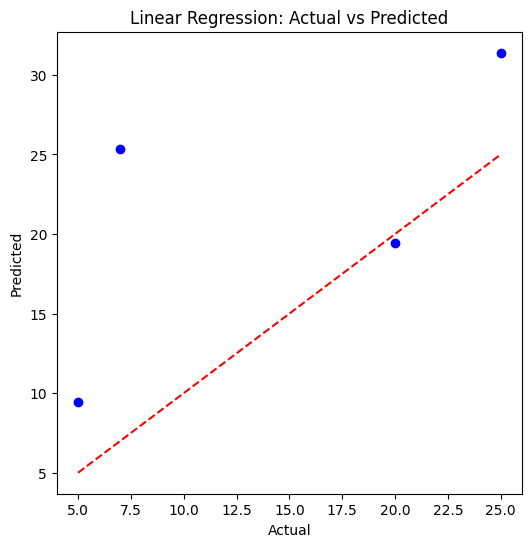

Random Forest Results:
R2 Score: 0.9886337401918047
RMSE: 0.9026731135909615


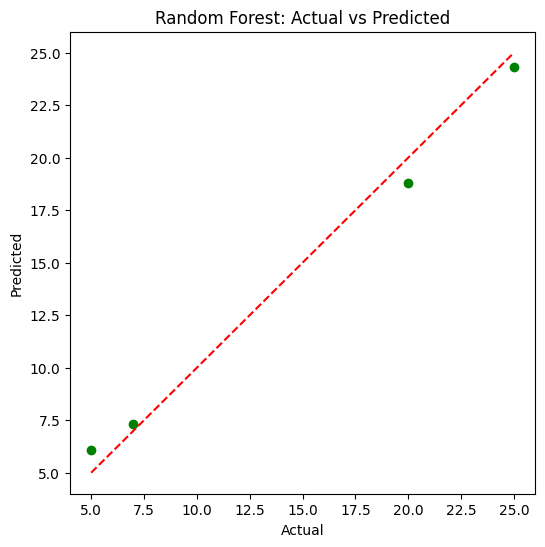

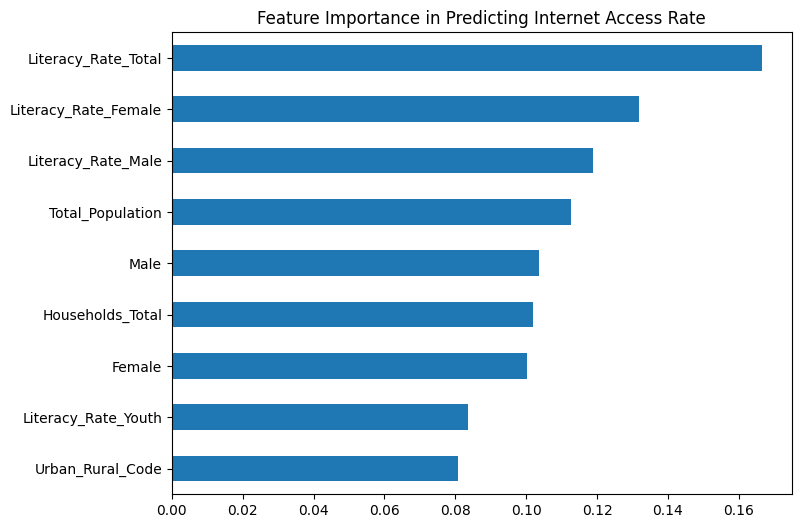

Cross-Validation R2 Scores: [0.94036623 0.92788748 0.92749985 0.40679744 0.96360197]
Mean CV R2 Score: 0.8332305930246072
Predictions (first 5 rows):
    Electricity_Access_Rate  Radio_Access_Rate  TV_Access_Rate  \
0                 81.772474          39.820996       55.742975   
1                 52.504741          47.359959       19.774376   
5                 51.355093          47.231207       19.224848   
14                79.836129          37.489589       51.098214   

    Telephone_Access_Rate  Internet_Access_Rate  
0               38.930219                24.325  
1               14.795647                 7.305  
5               12.877752                 6.100  
14              32.211654                18.775  
Actual values (first 5 rows):
    Electricity_Access_Rate  Radio_Access_Rate  TV_Access_Rate  \
0                 81.818182          40.909091       54.545455   
1                 54.166667          47.916667       20.833333   
5                 52.083333          50.0

In [4]:
# ============================================
# Cell 1: Import Libraries & Load Data

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv("../../data_processed/df_2011.csv")



# Encode Urban_Rural as numeric
df["Urban_Rural_Code"] = df["Urban_Rural"].map({"Urban": 1, "Rural": 0})

# ============================================
# Cell 2: Prepare Features & Target
# ============================================
X = df[[
    "Total_Population",
    "Male",
    "Female",
    "Literacy_Rate_Total",
    "Literacy_Rate_Male",
    "Literacy_Rate_Female",
    "Literacy_Rate_Youth",
    "Households_Total",
    "Urban_Rural_Code"
]]

y = df["Internet_Access_Rate"]  # Target column already present

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ============================================
# Cell 3: Linear Regression
# ============================================
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)

y_pred_lr = lr_model.predict(X_test_scaled)

print("Linear Regression Results:")
print("R2 Score:", r2_score(y_test, y_pred_lr))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_lr)))

# Plot actual vs predicted
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred_lr, color='blue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.title('Linear Regression: Actual vs Predicted')
plt.show()

# ============================================
# Cell 4: Random Forest Regression
# ============================================
rf_model = RandomForestRegressor(n_estimators=200, max_depth=5, random_state=42)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

print("Random Forest Results:")
print("R2 Score:", r2_score(y_test, y_pred_rf))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_rf)))

# Plot actual vs predicted
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred_rf, color='green')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.title('Random Forest: Actual vs Predicted')
plt.show()

# ============================================
# Cell 5: Feature Importance (Random Forest)
# ============================================
feat_importances = pd.Series(rf_model.feature_importances_, index=X.columns)
feat_importances.sort_values(ascending=True).plot(kind="barh", figsize=(8,6))
plt.title("Feature Importance in Predicting Internet Access Rate")
plt.show()

# ============================================
# Cell 6: Cross-Validation Scores
# ============================================
scores = cross_val_score(rf_model, X, y, cv=5, scoring="r2")
print("Cross-Validation R2 Scores:", scores)
print("Mean CV R2 Score:", scores.mean())

# ============================================
# Cell 7: Multi-Output Regression (Predict all tech access rates)
# ============================================
from sklearn.multioutput import MultiOutputRegressor

y_multi = df[["Electricity_Access_Rate","Radio_Access_Rate","TV_Access_Rate","Telephone_Access_Rate","Internet_Access_Rate"]]
multi_rf = MultiOutputRegressor(RandomForestRegressor(n_estimators=200, random_state=42))
multi_rf.fit(X_train, y_multi.iloc[X_train.index])

# Predictions for test set
y_multi_pred = multi_rf.predict(X_test)

# Compare first 5 predictions vs actuals
pred_df = pd.DataFrame(y_multi_pred, columns=y_multi.columns, index=X_test.index)
print("Predictions (first 5 rows):")
print(pred_df.head())
print("Actual values (first 5 rows):")
print(y_multi.iloc[X_test.index].head())
